In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, Image

<IPython.core.display.Javascript object>

# Ecuaciones Diferenciales Ordinarias.

---

## Ecuaciones diferenciales de primer Orden en una variable.

El problema reside en resolver ecuaciones no separables de forma numérica (aquellas que no tienen solución analítica).

---

### El método de Euler.

- Si se quiere saber el valor de $x$ en un tiempo $t+h$ se hace:

$$x(t+h)=x(t)+h\frac{dx}{dt}+\frac{1}{2}h^2\frac{d^2x}{dt^2}+\cdots=x(t)+h f(x,t)+{\cal O}(h)^2.$$


- Sabiendo el valor de $x$ para un tiempo $t$ esta ecuación nos permite calcular el valor de x un tiempo $x+h$ después. 


- Partiendo por tanto de nuestra condición inicial o de frontera, podemos iterar esta ecuación para obtener $x$ en un conjunto de puntos equiespaciados por una distancia $h$.


- Si el valor de nuestro paso, $h$, es suficientemente pequeño, esto nos permitirá obtener una buena descripción de nuestra solución.

---

#### Ejemplo:

Aplicar el método de Euler para resolver la ecuación:

$$\frac{\text{d}x}{\text{d}t}=-x^3+\sin t,$$

en el intervalo $[0,10]$ usando 1000 puntos equiespaciados con la condición inicial $x(t=0)=0$.

---

The estimated error of the computation is 0.0031293147138999763


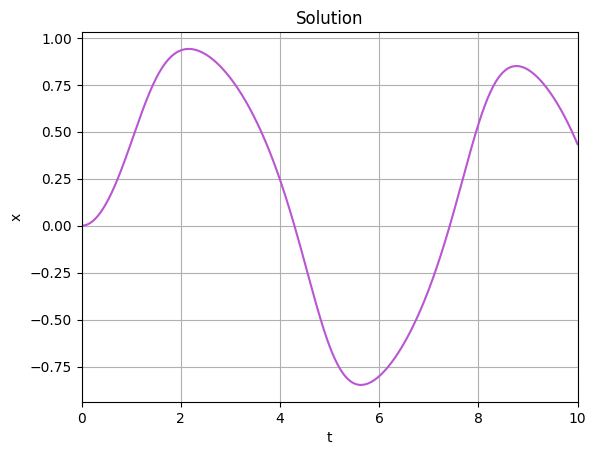

In [3]:
def f(x, t):
    return -x**3 + np.sin(t)


def euler(g, a, b, N, x0, plot_flag = False):
    h = (b - a) / N
    t_points = np.linspace(a, b, N)
    x_points = []
    x = x0

    for t in t_points:
        x_points.append(x)
        x += h * g(x, t)

    t = np.array(t_points, float)
    x = np.array(x_points, float)

    error = 0.5 * h * (g(x[-1], b) - g(x[0], a))
    print("The estimated error of the computation is", abs(error))

    if plot_flag:
        plt.plot(t, x, color = mc)
        plt.title("Solution")
        plt.xlabel("t")
        plt.ylabel("x")
        plt.xlim(a, b)
        plt.grid()
        plt.show()

    return t, x


t, x = euler(f, 0, 10, 1000, 0, True)


### Método de Runge-Kutta.

- Se puededen incluir más términos en el desarrollo de Taylor de la solución para reducir el erro del método de Euler, lo cual requiere evaluar la derivada de la función. Esto es problemático porque:

    1. En muchas ocasiones no conocemos la derivada de la función. 
    2. Incluso si lo hacemos, trabajar con ella vuelve el método menos eficiente y en muchos casos menos preciso.
   
- La segunda alternativa esta asociada a los métodos que vimos para aumentar la precisión de las derivadas numéricas:  
  escoger los puntos en los que evaluamos la solución para que al combinarlos, los términos superiores del desarrollo de Taylor se cancelen.
  
- Esta segunda alternativa es la base de los métodos de Runge-Kutta.

- A primer orden, el método de Runge-Kutta es el método de Euler. La derivada de la solución en la serie de Taylor en el punto $t+h$ se evaluar en $t$.

- A segundo orden, el método de Runge-Kutta evalúa la función en el punto que garantiza que el término ${\cal O}(h^2)$ de la serie de Taylor se cancela.

- El conjunto de ecuaciones necesarias para evaluar el método son:

    \begin{aligned}
    k_1 = h\,f\left(x,t\right) \hspace{5mm}
    k_2 = h\,f\left(x+\frac{1}{2}k_1,\,t+\frac{1}{2}h\right) \hspace{5mm}
    x(t+h) = x(t)+k_2

    \end{aligned}

  que aplicadas secuencialmente e iterativamente a partir de una condición inicial, nos permiten obtener nuestra solución en todo el intervalo de interés. 

---

The estimated error of the computation is 0.0031293147138999763


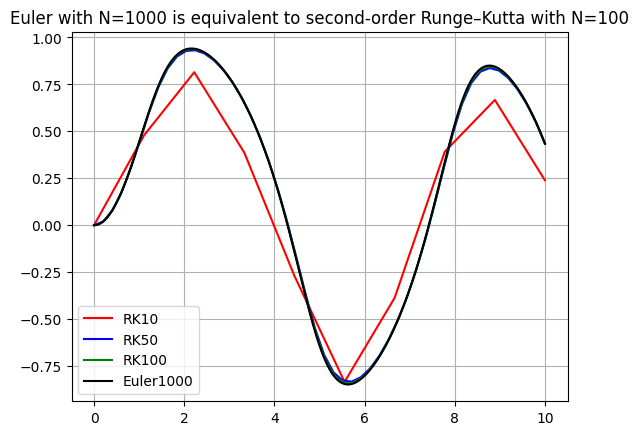

In [4]:
def rhs(x, t):
    return -x**3 + np.sin(t)


def runge_kutta_2(rhs, a, b, n, x0, display=False):
    h = (b - a) / n
    tp = np.linspace(a, b, n)
    xp = []
    x = x0

    for t in tp:
        xp.append(x)
        k1 = h * rhs(x, t)
        k2 = h * rhs(x + k1 / 2, t + h / 2)
        x += k2

    t = np.array(tp, float)
    x = np.array(xp, float)

    if display:
        plt.plot(t, x, color=mc)
        plt.title("Solution")
        plt.xlabel("t")
        plt.ylabel("x")
        plt.xlim(a, b)
        plt.grid()
        plt.show()

    return t, x


t1, x1 = runge_kutta_2(rhs, 0, 10, 10, 0)
t2, x2 = runge_kutta_2(rhs, 0, 10, 50, 0)
t3, x3 = runge_kutta_2(rhs, 0, 10, 100, 0)
t4, x4 = euler(rhs, 0, 10, 1000, 0)

plt.plot(t1, x1, color="r")
plt.plot(t2, x2, color="b")
plt.plot(t3, x3, color="g")
plt.plot(t4, x4, color="k")
plt.grid()
plt.legend(["RK10", "RK50", "RK100", "Euler1000"])
plt.title("Euler with N=1000 is equivalent to second-order Runge–Kutta with N=100")
plt.show()


### Método de Runge-Kutta de cuarto orden.

- Los algoritmos para los métodos de Runge-Kutta se vuelven más y más complicados a medida que aumentamos el orden.

- En general se considera que el de orden 2 es el que optimiza el cociente precisión versus complejidad.

- En particular, el algoritmo de cuarto orden más usado viene dado por el sistema de ecuaciones:

    \begin{align}
    k_1=&\,hf(x,t),\nonumber\\
    k_2=&h\,f\left(x+k_1/2,t+h/2\right),\nonumber\\
    k_3=&h\,f\left(x+k_2/2,t+h/2\right),\nonumber\\
    k_4=&h\,f\left(x+k_3,t+h\right),\nonumber\\
    x(t+h)=&\,x(t)+\frac{1}{6}\left(k_1+2k_2+2k_3+k_4\right).\nonumber\\
    \end{align}

    que es preciso hasta el orden $h^4$, es decir su error es ${\cal O}(h^5)$.


- El método de Runge-Kutta es el más usado para resolver ecuaciones diferenciales ordinarias, y en general el más fiable para problemas generales.

---

The estimated error of the computation is 0.0031293147138999763


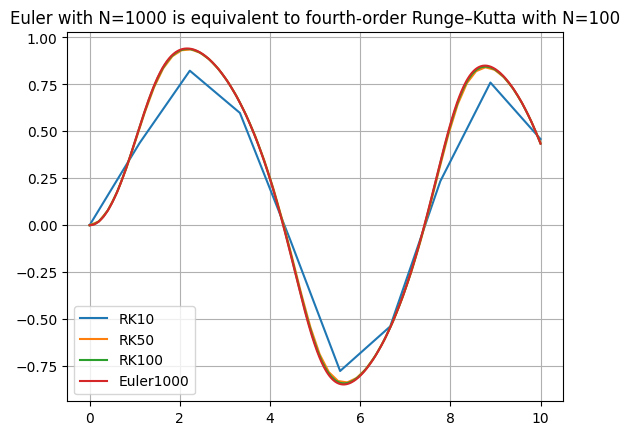

In [5]:
def rhs(x, t):
    return -x**3 + np.sin(t)


def runge_kutta_4(rhs, a, b, n, x0, display=False):
    h = (b - a) / n
    tp = np.linspace(a, b, n)
    xp = []
    x = x0

    for t in tp:
        xp.append(x)
        k1 = h * rhs(x, t)
        k2 = h * rhs(x + k1 / 2, t + h / 2)
        k3 = h * rhs(x + k2 / 2, t + h / 2)
        k4 = h * rhs(x + k3, t + h)
        x += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    t = np.array(tp, float)
    x = np.array(xp, float)

    if display:
        plt.plot(t, x)
        plt.title("Solution")
        plt.xlabel("t")
        plt.ylabel("x")
        plt.xlim(a, b)
        plt.grid()
        plt.show()

    return t, x


t1, x1 = runge_kutta_4(rhs, 0, 10, 10, 0)
t2, x2 = runge_kutta_4(rhs, 0, 10, 50, 0)
t3, x3 = runge_kutta_4(rhs, 0, 10, 100, 0)
t4, x4 = euler(rhs, 0, 10, 1000, 0)

plt.plot(t1, x1)
plt.plot(t2, x2)
plt.plot(t3, x3)
plt.plot(t4, x4)
plt.grid()
plt.legend(["RK10", "RK50", "RK100", "Euler1000"])
plt.title("Euler with N=1000 is equivalent to fourth-order Runge–Kutta with N=100")
plt.show()

### Soluciones sobre rangos infinitos.

- Se encuentran mediante un cambio de variable.:

    $$u=\frac{t}{1+t}\Rightarrow t=\frac{u}{1-u},$$

    que cumple que para $t\to\infty$ la nueva variables vale $u\to1$, nuestra ecuación diferencial se puede escribir como

    $$\frac{\text{d}x}{\text{d}u}\frac{\text{d}u}{\text{d}t}=f(x,t)\;\Rightarrow\; \frac{\text{d}x}{\text{d}u}=\frac{\text{d}t}{\text{d}u}f\left(x,\frac{u}{(1-u)}\right)=\left(1-u\right)^{-2}f\left(x,\frac{u}{(1-u)}\right).$$


- Por tanto, llamando:

    $$g(x,u)=\left(1-u\right)^{-2}f\left(x,\frac{u}{(1-u)}\right),$$

    nuestro problema inicial se puede escribir como:

    $$\frac{\text{d}x}{\text{d}u}=g(x,u),$$

    que es una nueva ecuación de primer orden. Al resolverla en el intervalo $u\in[0,1]$ estamos obteniendo nuestra ecuación original para $t\in[0,\infty)$.

---

#### Ejemplo:

Dada la ecuación diferencial

$$\frac{\text{d}x}{\text{d}t}=\frac{1}{x^2+t^2},$$

usar el método de  Runge-Kutta de cuarto orden para obtener su solución en el intervalo $t\in[0,\infty)$ con la condición inicial x(0)=1.  
Representarla en el intervalo [0,100].


Haciendo el cambio de variable $t=u\,/\,(1-u)$ tenemos:

$$\frac{\text{d}x}{\text{d}u}=\frac{1}{\left(1-u\right)^2x^2+u^2}=g(x,u),$$

con $u\in[0,1]$.

---

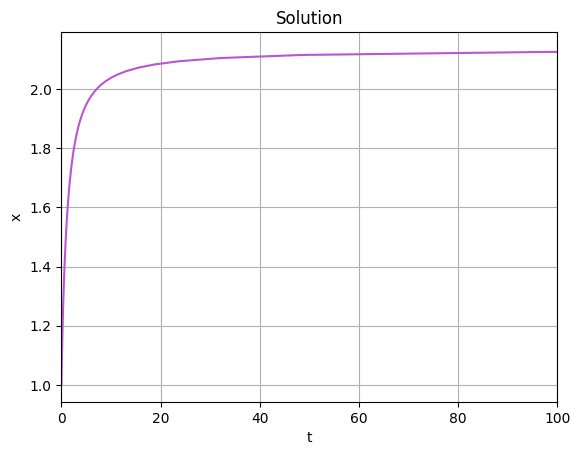

In [6]:
def runge_kutta_4_infinite(f, a, b, n, x0, x_lower, x_upper, plot=False):

    a /= (1 + a)
    b /= (1 + b)

    h = (b - a) / n
    u_points = np.linspace(a, b, n)

    x_points = []
    t_points = []

    x = x0

    for u in u_points:
        x_points.append(x)
        t_points.append(u / (1 - u))

        k1 = h * f(x, u)
        k2 = h * f(x + k1 / 2, u + h / 2)
        k3 = h * f(x + k2 / 2, u + h / 2)
        k4 = h * f(x + k3, u + h)

        x += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    x = np.array(x_points, float)
    t = np.array(t_points, float)

    if plot:
        plt.plot(t, x, color = mc)
        plt.title("Solution")
        plt.xlabel("t")
        plt.ylabel("x")
        plt.xlim(x_lower, x_upper)
        plt.grid()
        plt.show()

    return t, x

def g(x, u):
    return 1 / ((x**2) * (1 - u)**2 + u**2)


a = 0
b = 1e6
N = 100
x0 = 1

u, x = runge_kutta_4_infinite(g, a, b, N, x0, 0, 100, True)

## Sistemas de ecuaciones diferenciales ordinarias.

- Se tiene un sistema de ecuaciones diferenciales con dos variables $x(t)$, $y(t)$ que son exclusivamente función de $t$:

    $$\frac{\text{d}x}{\text{d}t}=f_x(x,y,t),\quad \frac{\text{d}y}{\text{d}t}=f_y(x,y,t),$$

    siendo $f_x$ y $f_y$ dos funciones, lineales o no lineales, de las variables $x,y,t$.


- En general, para un número arbitrario de variables y ecuaciones, el sistema se puede escribir en forma vectorial como:

    $$\frac{\text{d}\bf{r}}{\text{d}t}={\mathbf F}({\bf r},t),\quad\text{con}\quad{\bf r}=\left(x,y,\cdots\right),\quad\text{y}\quad{\mathbf F}({\bf r},t)=\left(f_x({\bf r},t),f_y({\bf r},t),\cdots\right),$$

    que nos permite interpretarla como una función de una sola variable y analizar su solución como hemos hecho hasta ahora. 


- Por ejemplo, desarrollando la solución en ${\bf r}(t+h)$ serie de Taylor tenemos:

    $${\bf r}(t+h)={\bf r}(t)+h\frac{{\text d}{\bf r}(t)}{\text{d}t}+{\cal O}\left(h^2\right)={\bf r}(t)+h\,{\mathbf F}({\bf r},t)+{\cal O}\left(h^2\right),$$

    que despreciando el término en $h^2$ nos lleva a la generalización del método de Euler para más de una variable. 


- De la misma forma, el método de Runge-Kutta de cuarto orden para sistemas de ecuaciones diferenciales vendrá dado por:

\begin{align}
{\bf k_1}=&h\,{\bf F}({\bf r},t),\nonumber\\
{\bf k_2}=&h\,{\bf F}({\bf r}+{\bf k_1}/2,t+h/2),\nonumber\\
{\bf k_3}=&h\,{\bf F}({\bf r}+{\bf k_2}/2,t+h/2),\nonumber\\
{\bf k_4}=&h\,{\bf F}({\bf r}+{\bf k_3},t+h),\nonumber\\
{\bf r}\left(t+h\right)=&r(t)+\,\frac{1}{6}({\bf k_1}+2{\bf k_2}+2{\bf k_3}+{\bf k_4}),\nonumber\\
\end{align}


- Estas ecuaciones pueden implementarse directamente en python haciendo uso de que es un lenguaje vectorial: permite operar con vectores, que pueden jugar el papel tanto de argumentos como resultado de una función.

---

#### Ejemplo:

Dado el sistema de ecuaciones diferenciales

$$\frac{\text{d}x}{\text{d}t}=xy-x,\quad \frac{\text{d}y}{\text{d}t}=y-xy+\sin^2\omega t,$$

con $\omega=1$, encontrar su solución en el intervalo $t\in[0,10]$, con x(0)=y(0)=1.

---

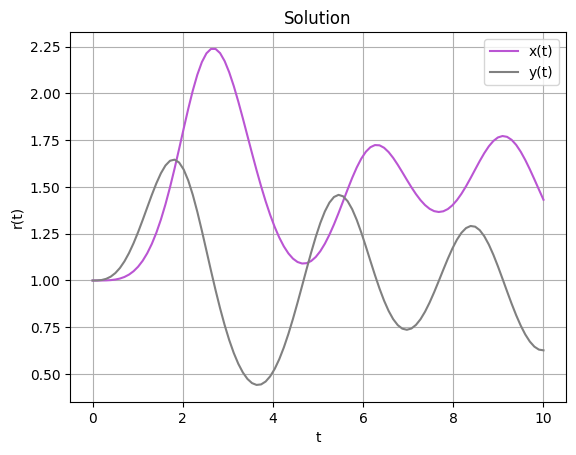

In [7]:
def F(r, t):
    x = r[0]
    y = r[1]
    fx = x * y - x
    fy = y - x * y + (np.sin(t))**2
    return np.array([fx, fy], float)


def rk4_system(F, a, b, N, x0, y0, plot=False):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    yp = []
    r = np.array([x0, y0], float)

    for t in tp:
        xp.append(r[0])
        yp.append(r[1])
        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    t = np.array(tp, float)
    x = np.array(xp, float)
    y = np.array(yp, float)

    if plot:
        plt.plot(t, x, color = mc)
        plt.plot(t, y, color = 'gray')
        plt.title("Solution")
        plt.grid()
        plt.legend(["x(t)", "y(t)"])
        plt.xlabel("t")
        plt.ylabel("r(t)")
        plt.show()

    return t, x, y


a, b, N = 0, 10, 100
x0, y0 = 1, 1
t, x, y = rk4_system(F, a, b, N, x0, y0, True)


## Ecuaciones diferenciales de segundo orden.

- La forma general de una ecuación de segundo orden en una variable es

    $$\frac{\text{d}^2x}{\text{d}t^2}=f\left(x,\frac{\text{d}x}{\text{d}t},t\right),$$

    es decir una ecuación que puede involucrar, $x$, su derivada y el tiempo.


- La forma de lidiar con estas ecuaciones, es sin embargo, totalmente equivalente a los sistemas de ecuaciones ordinarias cuando uno tiene en cuenta que llamando

    $$\frac{\text{d}x}{\text{d}t}=y,$$

    nuestra ecuación se puede escribir como

    $$\frac{\text{d}y}{\text{d}t}=f(x,y,t),$$

    y por tanto, lo convierte en un sistema de dos ecuaciones con dos incógnitas.


- De forma análoga, para ecuaciones de orden superior tenemos de forma general el problema

    $$\frac{\text{d}^nx}{\text{d}t^n}=f\left(x,\frac{\text{d}x}{\text{d}t},\frac{\text{d}^2x}{\text{d}t^2},\cdots,\frac{\text{d}^{n-1}x}{\text{d}t^{n-1}},t\right),$$

    que podemos expresar como

    \begin{align}
    \frac{\text{d}x}{\text{d}t}=&y_1,\nonumber\\
    \frac{\text{d}y_1}{\text{d}t}=&y_2,\nonumber\\
    \frac{\text{d}y_2}{\text{d}t}=&y_3,\nonumber\\
    \vdots&\nonumber\\
    \frac{\text{d}y_{n}}{\text{d}t}=&f(x,y_1,y_2,\cdots,y_{n-1},t).\nonumber\\
    \end{align}


- De la misma forma, podemos generalizar un sistema de ecuaciones de orden 2 o superior tratando nuestras variables de forma vectorial; dado el sistema:

    $$\frac{\text{d}^2{\bf r}}{\text{d}t^2}=f\left({\bf r},\frac{\text{d}{\bf r}}{\text{d}t},t\right),$$

    podemos escribirlo como:

    $$\frac{\text{d}{\bf r}}{\text{d}t}={\bf s},\quad \frac{\text{d}{\bf s}}{\text{d}t}=f\left({\bf r},{\bf s},t\right).$$


- De forma general, si comenzamos con un sistema de $n$ ecuaciones de orden $m$ podremos convertirlas en un sistema de $m\times n$ ecuaciones de primer orden, que podremos resolver con los métodos que hemos estudiado hasta ahora.

---

#### Ejemplo:

Aunque un problema habitual de los primeros cursos en física es el estudio del péndulo lineal, su aproximación a través de una ecuación diferencial lineal, un péndulo real es non lineal.

Sea un péndulo de longitud $l$ y una masa $m$.

en función del ángulo que mide su desplazamiento con respecto a la vertical, las ecuaciones de Newton implican la ecuación dinámica 

$$\frac{\text{d}^2\theta}{\text{d}t^2}=-\frac{g}{l}\sin\theta.$$

1. Escribir un programa que permita describir el movimiento de un péndulo no lineal durante 10 periodos, con  $l = 10$ cm que parte del reposo con un ángulo inicial de  $\theta = 179^\circ$ usando el método de Runge-Kutta de cuarto orden.


2. Describir por medio de una animación el movimiento del péndulo.
---

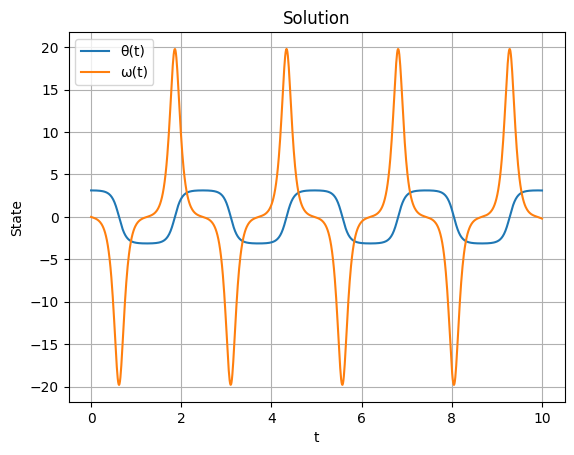

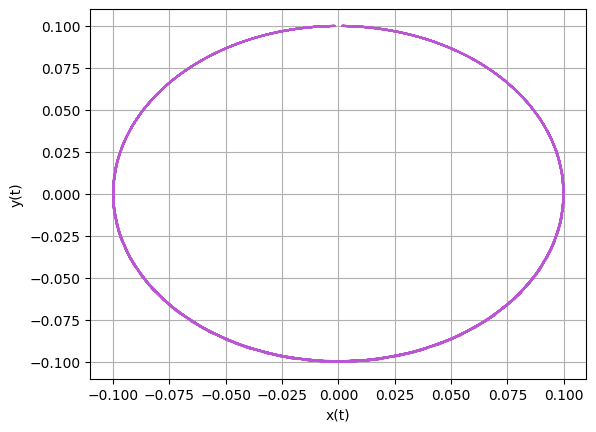

In [8]:
def pendulum(r, t):
    g = 9.8
    l = 0.1
    x = r[0]
    y = r[1]
    fx = y
    fy = -g * np.sin(x) / l
    return np.array([fx, fy], float)


def nonlinear_pendulum(F, a, b, N, x0, y0, plot=False):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    yp = []
    xc = []
    yc = []

    r = np.array([x0, y0], float)
    l = 0.1
    x = l * np.sin(r[0])
    y = -l * np.cos(r[0])

    for t in tp:
        xp.append(r[0])
        yp.append(r[1])
        xc.append(x)
        yc.append(y)

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

        x = l * np.sin(r[0])
        y = -l * np.cos(r[0])

    t = np.array(tp, float)
    x = np.array(xp, float)
    y = np.array(yp, float)
    xc = np.array(xc, float)
    yc = np.array(yc, float)

    if plot:
        plt.plot(t, x)
        plt.plot(t, y)
        plt.title("Solution")
        plt.grid()
        plt.legend(["θ(t)", "ω(t)"])
        plt.xlabel("t")
        plt.ylabel("State")
        plt.show()

    return t, x, y, xc, yc


a, b, N = 0, 10, 1000
x0, y0 = np.radians(179), 0
t, x, y, xc, yc = nonlinear_pendulum(pendulum, a, b, N, x0, y0, True)

plt.plot(xc, yc, color = mc)
plt.grid()
plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.show()

### Método de Runge-Kutta con paso adaptado.

1. Definimos una precisión objetivo $\epsilon_\text{obj}=h\delta$.


2. Partiendo de nuestra condición inicial, realizamos dos pasos de anchura $h$, y uno de anchura $2h$ lo cual nos permite obtener el cociente $\rho$.

$$\rho=\frac{30h\delta}{\vert x_1-x_2\vert},$$


3. Si $\rho>1$ nuestra precisión es mayor que la objetivo. Nos movemos al punto $t+2h$, pero actualizamos el paso a $h'=h\rho^{1/4}$, de forma que no utilizamos pasos más pequeños de los necesarios.  
   Si $\rho<1$, nuestro resultado no esta alcanzando la precisión deseada. Volvemos al punto 2 pero usando como paso $h'$.


- En resumen, después de cada paso, dependiendo del valor de $\rho$, o aumentamos el valor del paso y nos movemos al siguiente punto o lo disminuimos y repetimos el mismo paso. 


- Para cada estimación tenemos dos valores, $x_1$ y $x_2$, aunque obviamente, al ser $x_1$ más preciso usaremos ese valor. 


- En general, los métodos de Runge-Kutta de paso adaptado involucran más esfuerzo que las que usan un paso fijo (hacemos como mínimo tres estimaciones de Runge-Kutta para obtener sólo dos valores). 


- Sin embargo, el esfuerzo merece la pena. 

    1. Nuestro resultados garantiza que cumple la precisión objetivo.
    2. El programa suele tardar menos tiempo en ejecutarse, pues permite optimizar el paso en aquellos intervalos donde la función es suave.
    
    
- Es posible que en un paso dado el valor de $x_1$ y $x_2$ casi coincidan de forma accidental. Si eso ocurriese, el valor de $h'$ podría hacerse muy grande.   
  Para evitar ese problema se suele definir un incremento máximo del valor del paso en cada iteración.  
  Por lo general se suele imponer que no aumente más del doble de su valor actual.

---

### Sistemas de ecuaciones diferenciales con paso adaptado.

- Los métodos con paso adaptativo pueden generalizarse a sistemas de ecuaciones. 


- El único problema es que tendremos un error asociado a cada una de nuestras ecuaciones. 


- Dado el sistema de ecuaciones

    $$\frac{\text{d}x}{\text{d}t}=f_x(x,y,t),\quad \frac{\text{d}y}{\text{d}t}=f_y(x,y,t),$$

    nos encontraremos un error asociado a la ecuación para la variable $x$ y otro para $y$

    $$\epsilon_x=\frac{1}{30}(x_1-x_2),\quad \epsilon_y=\frac{1}{30}(y_1-y_2).$$


- El problema es por tanto definir como combinamos ambos errores para definir el cociente entre nuestro error y la tolerancia deseada. 


- La forma de hacerlo dependerá del problema:
<br/>
    
    - Si $x$ e $y$ representan coordenadas en un espacio de dos dimensiones el error total puede definirse como su error euclídeo $\sqrt{\epsilon_x^2+\epsilon_y^2}$.
    - Si el sistema proviene de una ecuación diferencial de dos variables, obviamente el único error relevante será el asociado a la variable original.

---

### Método del salto de la rana.

- En la segunda iteración en vez de usar el método de Euler para calcular la solución en $x(t+3h/2)$, usa el método del punto medio partiendo del punto $x(t+h/2)$

    \begin{align}
    x(t+h/2)=&x(t)+h/2f(x,t),\nonumber\\
    x(t+h)=&x(t)+hf(x(t+h/2),t+h/2),\nonumber\\
    x(t+3h/2)=&x(t+h/2)+hf(x(t+h),t+h),\nonumber\\
    \end{align}

    resultado que podemos usar para calcular el siguiente paso:

    $$x(t+2h)=x(t+h)+hf(x(t+3h/2),t+3h/2),$$

    lo cual permite definir un algoritmo iterativo. 


- El método es también de orden 2, con un error ${\cal O}(h^3)$ y puede extenderse a sistemas de ecuaciones sustituyendo $x$ por el vector ${\bf r}$ y $f$ por el vector ${\bf F}$.

    \begin{align}
    {\bf r}(t+h)=&{\bf r}(t)+h{\bf F}({\bf r}(t+h/2),t+h/2),\nonumber\\
    {\bf r}(t+3h/2)=&{\bf r}(t+h/2)+h{\bf F}({\bf r}(t+h),t+h).\nonumber\\
    \end{align}

---

#### Ejemplo:

Aplicar el método del salto de la rana a la ecuación diferencial

$$\frac{\text{d}^2x}{\text{d}t^2}=\left(\frac{\text{d}x}{\text{d}t}\right)^2-x-5,$$

usando el método del salto de la rana en el intervalo $t\in[0,50]$, con un paso h=0.001 y usando las condiciones iniciales $x(0)=1$, $v(0)=0$.   
Representar la solución como función del tiempo.

---

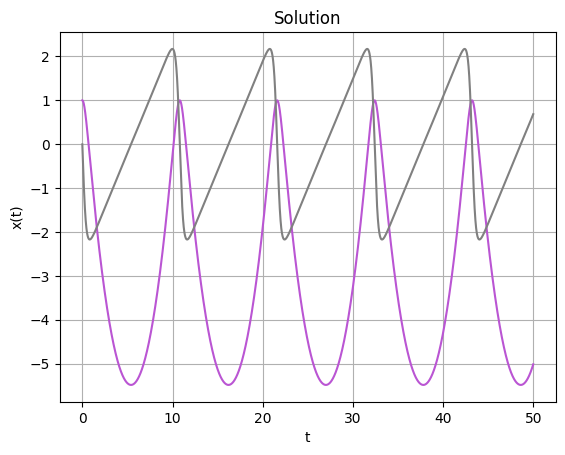

In [9]:
def F(r):
    x = r[0]
    y = r[1]

    fx = y
    fy = y**2 - x - 5

    return np.array([fx, fy], float)


def leapfrog(F, a, b, N, r):
    h = (b - a) / N

    tp = np.arange(a, b, h)
    xp = []
    yp = []

    r1 = np.array([r[0], r[1]], float)
    r2 = r1 + h * F(r1) / 2

    for t in tp:
        xp.append(r1[0])
        yp.append(r2[1])
        r1 += h * F(r2)
        r2 += h * F(r1)

    return tp, xp, yp


a, b, N = 0, 50, 5e4
r = [1, 0]

t, x, y = leapfrog(F, a, b, N, r)

plt.plot(t, x, color = mc)
plt.plot(t, y, color = 'gray')
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution")
plt.grid()
plt.show()


### Método de Verlet.

- Es un caso particular del método del salto de la rana para estudiar las ecuaciones del movimiento de un sistema físico. 


- Sea la ecuación de movimiento

  $$\frac{\text{d}^2x}{\text{d}t^2}=f(x,t),$$

  ya hemos visto que la podemos descomponer en un sistema de dos ecuaciones diferenciales ordinarias

  $$\frac{\text{d}x}{\text{d}t}=v,\quad\frac{\text{d}v}{\text{d}t}=f(x,t).$$


- En vez de tratarlas de forma vectorial, apliquemos ahora el método del salto de la rana a cada una de ellas.  


- Asumamos que las condiciones iniciales nos fijan $x(t)$, el valor de la solución en el instante $t$, y  $v(t+h/2)$, la velocidad en el instante $t+h/2$.   
  Aplicando el método de la rana tenemos entonces:
  
    \begin{align}  
    x(t+h)=&x(t)+hv(t+h/2),\nonumber\\
    v(t+3h/2)=&v(t+h/2)+hf(x(t+h),t+h).\nonumber\\
    \end{align}


- Que definen un sistema en el que sólo tenemos que conocer la solución en múltiples enteros de $h$ y la velocidad en múltiplos semienteros $h/2$.


- Esto supone una mejora con respecto aplicar el método del salto de la rana al vector $(x,v)$, pues en ese caso tendríamos que calcular la posición y velocidad en todos los puntos. 


- El único problema es puede ser que sólo conozcamos la velocidad en el instante $t$ no en $t+h/2$.   
  En ese caso, partiendo de $v(t)$, aplicamos Euler con paso $h/2$

    $$v(t+h/2)=v(t)+\frac{1}{2}h f(x(t),t),$$


- También es posible que necesitemos estimar algún observable que requiera conocer la posición y velocidad en el mismo instante, por ejemplo la energía total del sistema. En ese caso, aplicando Euler de nuevo con paso $h/2$ se tiene

    $$v(t+h)=v(t+h/2)+\frac{1}{2}h f(x(t+h),t+h).$$


- Con todas estas ecuaciones podemos definir un algoritmo para tratar con este tipo de problemas. Dadas las condiciones iniciales x(t) y v(t) tenemos

    \begin{align}
    v(t+h/2)=&v(t)+\frac{1}{2}h f(x(t),t)\nonumber\\
    x(t+h)=&x(t)+hv(t+h/2),\nonumber\\
    k=&hf(x(t+h),t+h),\nonumber\\
    v(t+h)=&v(t+h/2)+\frac{1}{2}k,\nonumber\\
    v(t+3h/2)=&v(t+h/2)+hk\nonumber\\
    \end{align}

    que es el llamado método de Verlet. 

---

In [ ]:
def verlet(F, a, b, N, r, print=False):
    h = 3600

    pos = np.array([r[0], r[1]], float)
    vel = np.array([r[2], r[3]], float)
    v2 = vel + 0.5 * h * F(pos)

    tp = np.arange(a, b, h)
    xp = []
    yp = []
    Vp = []
    Tp = []
    Ep = []

    for t in tp:
        xp.append(pos[0])
        yp.append(pos[1])
        Vp.append(V(pos))
        Tp.append(T(vel))
        Ep.append(V(pos) + T(vel))

        pos += h * v2
        k = h * F(pos)
        vel = v2 + 0.5 * k
        v2 += k

    if print:
        plt.plot(xp, yp)
        plt.xlabel("x(t)")
        plt.ylabel("y(t)")
        plt.title("Solution")
        plt.grid()
        plt.show()

    return tp, xp, yp, Vp, Tp, Ep


### Método de Bulirsch-Stoer.

Definimos una precisión objetivo por unidad de tiempo y dividimos nuestro solución en $N$ subintervalos de longitud $H$. A cada uno de estos subintervalos le aplicamos el siguiente algoritmo:

1. Usamos el método del punto medio modificado para obtener la estimación $R_{1,1}$ de la solución en $x(t+H)$ usando un sólo paso.


2. Incrementamos el número de pasos $n$ en uno, y obtenemos una nueva estimación del punto medio modificado con ese número de puntos $R_{n,1}$.


3. Usamos la ecuación 

    $$R_{n,m+1}=R_{n,m}+\frac{R_{n,m}-R_{n-1,m}}{\left[n/(n-1)\right]^{2m}-1},$$

    para obtener los valores de $R{n,2},\cdots,R_{n,n}$ correspondientes a la fila $n$.


4. Después de calcular la final completa comparamos el error de nuestra estimación

    $$c_m h_n^{2m}=\frac{R_{n,m}-R_{n-1,m}}{\left[n/(n-1)\right]^{2m}-1},$$

    con la precisión objetivo $\delta H$. Si el error es mayor que la tolerancia volvemos al punto 2. De otra forma nos movemos al siguiente subintervalo $H$.

---

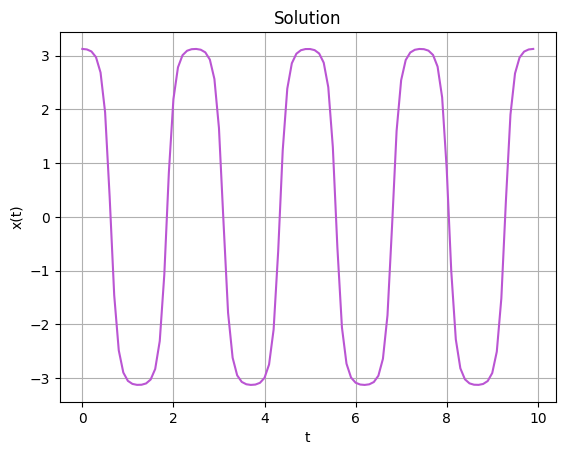

In [11]:
def pendulo(r):
    g = 9.8
    l = 0.1

    x = r[0]
    y = r[1]

    fx = y
    fy = -g * np.sin(x) / l

    return np.array([fx, fy], float)


def bulirsch2(F, a, b, H, r, delta, print=False):
    tpp = np.arange(a, b, H)
    xpp = []
    ypp = []

    r = np.array(r, float)

    for t in tpp:
        xpp.append(r[0])
        ypp.append(r[1])

        n = 1
        r1 = r + 0.5 * H * F(r)
        r2 = r + H * F(r1)

        R1 = np.zeros((n, 2), float)
        R1[0] = 0.5 * (r1 + r2 + 0.5 * H * F(r2))

        error = 2 * H * delta

        while error > H * delta:
            n += 1
            h = H / n

            r1 = r + 0.5 * h * F(r)
            r2 = r + h * F(r1)

            for _ in range(n - 1):
                r1 += h * F(r2)
                r2 += h * F(r1)

            R2 = R1
            R1 = np.zeros((n, 2), float)
            R1[0] = 0.5 * (r1 + r2 + 0.5 * h * F(r2))

            for m in range(1, n):
                eps = (R1[m - 1] - R2[m - 1]) / ((n / (n - 1)) ** (2 * m) - 1)
                R1[m] = R1[m - 1] + eps

            error = abs(eps[0])

        r = R1[n - 1]

    if print:
        plt.plot(tpp, xpp, color = mc)
        plt.grid()
        plt.xlabel("t")
        plt.ylabel("x(t)")
        plt.title("Solution")
        plt.show()

    return tpp, xpp, ypp


a = 0
b = 10
H = 0.1
r = [np.radians(179), 0]

t, x, y = bulirsch2(pendulo, a, b, H, r, 1e-8, 1)

## Problemas con condiciones de contorno o de frontera.

---

### Método del disparo.

-  Imaginemos por ejemplo el caso de la figura, en el que lanzamos un objeto hacía arriba sabiendo que debe alcanzar el suelo al cabo de un tiempo $t_1$.
<br/>

    - Conocemos la posición inicial pero no la velocidad inicial. 
    
    - Hacemos por tanto una conjetura sobre la velocidad inicial del proyectil e integramos la ecuación  hasta $t_1$, en el que el objeto se supone debe haber aterrizado $x(t_1)=0$.
    <br>
    
    - Si no es caso, habremos disparado demasiado fuerte o demasiado flojo y deberemos empezar de nuevo modificando nuestra estimación inicial de la velocidad.  


- Dicho de otra forma, la ecuación diferencial nos permite obtener una función $f$ tal que

    $$x=f(v).$$

-  Nuestro problema de contorno consiste por tanto en encontrar la solución a la ecuación, 

    $$f(v)=0,$$

    algo que hemos aprendido a hacer en el tema 5. 


- Los problemas de contorno implican por tanto:

    1. Usar los métodos para resolver ecuaciones diferenciales, por ejemplo el método de Runge-Kutta de orden 4, para calcular el valor de la función $f(v)$,  que nos relaciona un problema de condiciones iniciales con uno de condiciones de contorno.
<br>

    2. Usar los métodos para buscar raíces de funciones para encontrar las condiciones iniciales que satisfacen las condiciones de contorno.

---

#### Ejemplo:

Sea una pelota lanzada en vertical desde el suelo. Resolver el problema de contorno sabiendo que la pelota debe alcanzar el suelo al cabo de 10 s.

---

In [12]:
def bisection(f, a, b, c, eps):
    fa = f(c, a)
    fb = f(c, b)
    it = 0

    while b - a > eps:
        m = (a + b) / 2
        fm = f(c, m)
        it += 1

        if np.sign(fa) == np.sign(fm):
            a = m
            fa = fm
        else:
            b = m
            fb = fm

    print("Iterations for the bisection method:", it)
    return m


def F(r):
    g = 9.8

    x = r[0]
    vx = r[1]

    fx = vx
    fvx = -g

    return np.array([fx, fvx], float)


a = 0
b = 10
N = 1000
h = (b - a) / N


def height(x0, v0):
    r = np.array([x0, v0], float)
    tp = np.linspace(a, b, N)

    for t in tp:
        k1 = h * F(r)
        k2 = h * F(r + k1 / 2)
        k3 = h * F(r + k2 / 2)
        k4 = h * F(r + k3)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    return r[0]


def shot(f, v1, v2, x0, eps):
    h1 = f(x0, v1)
    h2 = f(x0, v2)

    while abs(h2 - h1) > eps:
        m = (v1 + v2) / 2
        hm = f(x0, m)

        if np.sign(h1) == np.sign(hm):
            v1 = m
            h1 = hm
        else:
            v2 = m
            h2 = hm

    return m


v1 = 0.01
v2 = 1000.0
x0 = 0
error = 1e-5

print(shot(height, v1, v2, x0, error))


48.99999907880089


## Métodos de Relajación.

---

### Método de diferencias finitas.

- Dividimos el intervalo de integración $(a,b)$ en $N$ subintervalos de longitud $h$. 

- Eso nos permite definir nuestra solución en un conjunto discreto de puntos (puntos de la maya) que denotamos $x_i$ con $x_i=0,\cdots,N$.

- Las derivadas de nuestra solución en la ecuación diferencial se calculan utilizando los métodos de diferencias finitas.


- Por ejemplo utilizando la aproximación del punto medio se tiene para la primera derivada que

    $$x'_i=\frac{x_{i+1}-x_{i-1}}{2h},$$

    mientras que para la segunda derivada el resultado sería

    $$x''_i=\frac{x_{i+1}-2x_i+x_{i-1}}{h^2}.$$


- De esta forma, la ecuación diferencial se puede escribir como $N+1$ ecuaciones simultaneas para N+1 incógnitas $x_0,\cdots,x_{N}$.


- Si las ecuaciones diferenciales son no-lineales, las ecuaciones algebraicas serán también no-lineales y deberemos resolverlas por el método de Newton-Raphson, relajación,...


- Si las funciones son lineales, podremos resolver el sistema utilizando por ejemplo la descomposición $LU$.


- Por ejemplo dada la ecuación de orden 2 y usando el método de relajación tendríamos

    $$\frac{\text{d}^2x}{\text{d}t^2}=f(x,t),$$

    definida en el intervalo $[0,H]$ con condiciones de contorno

    $$x(0)=x(H)=0,$$


1. Dividimos el intervalo $[0,H]$ en $N$ subintervalos.


2. Expresamos las derivadas segundas por medio de las diferencias centradas para discretizar la ecuación:

    $$\frac{x_{i+1}-2x_i+x_{i-1}}{h^2}-f(x_i,t_i)=0,$$

    que implica la ecuación

$$x_i=\frac{1}{2}\left(x_{i+1}-x_{i-1}-h^2f(x_i,t_i)\right),$$


- Usamos el método del punto fijo o relajación para resolver la ecuación obteniendo las iteraciones

    $$x_i^{(n+1)}=\frac{1}{2}\left(x_{i+1}^{(n)}-x_{i-1}^{(n)}-h^2f(x_i^{(n)},t_i)\right),$$

    para todos los valores de i con $0\le i \le N$.


- Análogamente al comentario que hicimos en los métodos iterativos de resolución de ecuaciones lineales y no lineales, a veces, se puede acelerar la convergencia utilizando un método SOR (Succesive Over Relaxation), de sobrerelajación. 


- Es decir, si definimos nuestra nueva estimación como

    $$x_i^{(n+1)}=x_i^{(n)}+\Delta x_i^{(n)},$$

    el método de sobrerelajación intentan acelerar la convergería del problema haciendo 

    $$x_i^{(n+1)}=x_i^{(n)}+(1+\omega)\Delta x_i^{(n)}.$$

    siendo $\omega$ es el parámetro de sobre relajación que en general $\omega \in [-1, 1]$.
<br/>
     
    - $\omega > 1$ usados habitualmente para acelerar los procesos de convergencia lenta.  
    - $\omega < 1$ usados habitualmente para para conseguir la convergencia de procesos iterativos divergentes.


- Usando el método de sobrerelajación nuestra estimación de la iteración $n+1$ se modificaría como

$$x_i^{(n+1)}=\frac{1+\omega}{2}\left(x_{i+1}^{(n)}-x_{i-1}^{(n)}-h^2f(x_i^{(n)},t_i)\right)-\omega x_i^{(n)},$$

---

#### Ejemplo:

1. Utilizar el método de relajación con diferencia finitas para resolver el problema de la bola lanzada al aire:

    $$\frac{\text{d}^2x}{\text{d}t^2}-g=0,$$

    con las condiciones de contorno $x(0)=x(10)=0$, con una tolerancia en la convergencia  del problema $\epsilon=10^{-6}$.


2. Usar ahora el método de sobrerelajación para obtener la misma solución. Encontrar el valor de $\omega$ que minimiza el número de iteraciones necesarias para converger con la precisión requerida.

---

Iterations: 22373


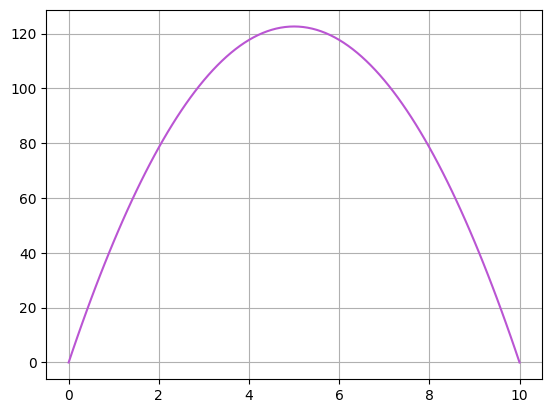

In [ ]:
g = 9.81
a, b, N = 0, 10, 100
h = (b - a) / N
eps = 1e-6

x = np.zeros(N + 1, float)
delta = 1.0
it = 0

while delta > eps:
    xp = np.empty(N + 1, float)
    xp[0] = 0.0
    xp[N] = 0.0
    xp[1:N] = 0.5 * (x[:N - 1] + x[2:N + 1] + g * h**2)
    delta = max(abs(x - xp))
    x = xp
    it += 1

print("Iterations:", it)

t = np.linspace(a, b, len(x))
plt.plot(t, x, color = mc)
plt.grid()
plt.show()
